# Replication notebook

This notebook reproduces the reported tables and figures from the files the
replication pipeline writes under `outputs/`. It reads results only; the
computation itself is done by the numbered stages in `replication/`, which
are listed in the first section. Run it from the repository root after the
pipeline has finished (or on a checkout that already holds `outputs/`):

```bash
uv sync --all-extras
uv run jupyter notebook replication/replication.ipynb   # or open it in VS Code
```

Every table below is computed from the stored per-game records, so the
numbers here are the numbers in the paper's tables, to the rounding shown.

## 1. The pipeline

The stages run in order and write to fixed paths; a stage skips any step
whose outputs already exist. `DRY_RUN=1` prints the commands without
executing anything, which is what the cell below does. To run the pipeline
for real, execute `replication/run_all.sh` from a terminal: it detaches under
`nohup caffeinate`, logs to `logs/`, and takes a few hours.

In [1]:
import os, subprocess
from pathlib import Path

# Work from the repository root whether the notebook was opened there or in replication/.
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "replication" / "run_all.sh").exists())
os.chdir(root)
print(subprocess.run(["bash", "replication/run_all.sh"], env={**os.environ, "DRY_RUN": "1"},
                     capture_output=True, text=True).stdout)

=== run_all ===
=== 00_data ===
skip: data/raw/player_game_logs.csv present (FORCE=1 to recompute)
skip: data/raw/shot_data.csv present (FORCE=1 to recompute)
skip: data/raw/starters.csv present (FORCE=1 to recompute)
skip: data/player_bio.csv present (FORCE=1 to recompute)
=== 01_snapshots ===
skip: data/snapshots_K4.pt present (FORCE=1 to recompute)
=== 02_count_head ===
skip: outputs/count_head_v1/modules.pt present (FORCE=1 to recompute)
=== 03_timing_head ===
skip: outputs/timing_head_v2_masked/modules.pt present (FORCE=1 to recompute)
=== 04_ac_kde ===
skip: outputs/joint_b2_outcome_residual_v1/modules.pt present (FORCE=1 to recompute)
=== 05_baselines ===
skip: outputs/baseline_kde/cloud_metrics.json outputs/baseline_kde/density_metrics.json present (FORCE=1 to recompute)
skip: outputs/mdn_v1/modules.pt outputs/mdn_v1/cloud_metrics.json outputs/mdn_v1/density_metrics.json present (FORCE=1 to recompute)
=== 06_evaluate ===
skip: outputs/joint_b2_outcome_residual_v1/cloud_metrics.

## 2. Loading the results

Each evaluator writes a JSON file with an `aggregate` block and a `per_game`
list keyed by `(player_id, game_idx)`, so results from different models can
be paired game by game.

In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

MAINLINE = Path("outputs/joint_b2_outcome_residual_v1")
RUNS = {
    "Reference KDE": Path("outputs/baseline_kde"),
    "Conditional MDN": Path("outputs/mdn_v1"),
    "AC-KDE": MAINLINE,
}
CLOUD_METRICS = {
    "energy_distance": "energy distance",
    "sliced_wasserstein": "sliced Wasserstein (ft)",
    "zone_l1": "zone L1",
    "rim_distance_w1": "rim-distance W1 (ft)",
    "rim_distance_ks": "rim-distance KS",
    "mean_shot_distance_err_ft": "mean shot-distance error (ft)",
}


def load(path):
    return json.loads(Path(path).read_text())


def aggregate(run_dir, which="cloud"):
    agg = load(run_dir / f"{which}_metrics.json")["aggregate"]
    return agg.get("model", agg)


def per_game(run_dir, which="cloud"):
    out = {}
    for rec in load(run_dir / f"{which}_metrics.json")["per_game"]:
        values = rec.get("model", rec)
        out[(str(rec["player_id"]), int(rec["game_idx"]))] = values
    return out


def paired_delta(a, b, metrics, n_boot=2000, seed=0):
    """Mean of (b - a) per game with a bootstrap 95% CI, over the games both runs scored."""
    rng = np.random.default_rng(seed)
    common = sorted(set(a) & set(b))
    rows = []
    for m in metrics:
        d = np.array([b[g][m] - a[g][m] for g in common], dtype=float)
        d = d[np.isfinite(d)]
        boot = np.array([d[rng.integers(0, len(d), len(d))].mean() for _ in range(n_boot)])
        lo, hi = np.percentile(boot, [2.5, 97.5])
        rows.append({"metric": CLOUD_METRICS.get(m, m), "delta": d.mean(), "ci_low": lo, "ci_high": hi,
                     "n_games": len(d)})
    return pd.DataFrame(rows).set_index("metric")


pd.set_option("display.precision", 3)

## 3. Finite-cloud metrics: reference KDE, MDN, and AC-KDE

Lower is better on every metric. The self-bootstrap floor is the value a
cloud resampled from the observed shots themselves attains; it is the
finite-sample noise level of each metric at these shot counts.

In [3]:
table = pd.DataFrame({name: aggregate(path) for name, path in RUNS.items()})
floor = load(MAINLINE / "cloud_metrics.json")["aggregate"].get("self_bootstrap")
if floor:
    table["self-bootstrap floor"] = pd.Series(floor)
table = table.loc[list(CLOUD_METRICS)].rename(index=CLOUD_METRICS)
table

,Reference KDE,Conditional MDN,AC-KDE,self-bootstrap floor
energy distance,0.258,0.239,0.154,-0.761
sliced Wasserstein (ft),3.533,3.458,3.380,2.059
zone L1,0.616,0.592,0.579,0.340
rim-distance W1 (ft),3.359,3.203,3.162,1.927
rim-distance KS,0.278,0.267,0.266,0.156
mean shot-distance error (ft),2.658,2.538,2.502,1.602


### Paired comparisons

The three models are scored on the same 2,000 validation player-games, so
each comparison is a per-game difference with a bootstrap confidence
interval. A positive delta means AC-KDE is better.

In [4]:
ac = per_game(MAINLINE)
pd.concat(
    {name: paired_delta(ac, per_game(path), CLOUD_METRICS) for name, path in RUNS.items() if name != "AC-KDE"},
    axis=1,
)

Reference KDE                         \
                                      delta ci_low ci_high n_games   
metric                                                               
energy distance                       0.103  0.084   0.123    2000   
sliced Wasserstein (ft)               0.153  0.134   0.174    2000   
zone L1                               0.037  0.033   0.041    2000   
rim-distance W1 (ft)                  0.197  0.162   0.233    2000   
rim-distance KS                       0.011  0.010   0.013    2000   
mean shot-distance error (ft)         0.156  0.113   0.200    2000   

                              Conditional MDN                             
                                        delta     ci_low ci_high n_games  
metric                                                                    
energy distance                     8.520e-02  6.653e-02   0.104    2000  
sliced Wasserstein (ft)             7.739e-02  5.866e-02   0.096    2000  
zone L1                             1.311e-02  9.912e-03   0.016    2000  
rim-distance W1 (ft)                4.078e-02  1.256e-02   0.070    2000  
rim-distance KS                     6.219e-04 -9.906e-04   0.002    2000  
mean shot-distance error (ft)       3.575e-02 -1.086e-03   0.071    2000

## 4. Density-surface scores

Scores of the predicted density as a forecast of where each shot lands:
smoothed log score at four bandwidths, zone-level Brier score and
cross-entropy, and the coverage of the 50%, 80% and 90% highest-density
regions. Lower is better for the scores; coverage should match its nominal
level.

In [5]:
DENSITY_METRICS = {
    "smoothed_log_score_1ft": "smoothed log score, 1 ft",
    "smoothed_log_score_2ft": "smoothed log score, 2 ft",
    "smoothed_log_score_4ft": "smoothed log score, 4 ft",
    "smoothed_log_score_8ft": "smoothed log score, 8 ft",
    "zone_brier": "zone Brier score",
    "zone_ce": "zone cross-entropy",
    "hdr_coverage_50": "HDR coverage at 50%",
    "hdr_coverage_80": "HDR coverage at 80%",
    "hdr_coverage_90": "HDR coverage at 90%",
}
density = pd.DataFrame({name: aggregate(path, "density") for name, path in RUNS.items()})
density.loc[list(DENSITY_METRICS)].rename(index=DENSITY_METRICS)

,Reference KDE,Conditional MDN,AC-KDE
"smoothed log score, 1 ft",6.547,6.403,6.453
"smoothed log score, 2 ft",6.674,6.575,6.592
"smoothed log score, 4 ft",6.954,6.911,6.899
"smoothed log score, 8 ft",7.394,7.374,7.357
zone Brier score,0.061,0.051,0.048
zone cross-entropy,1.807,1.777,1.768
HDR coverage at 50%,0.554,0.479,0.524
HDR coverage at 80%,0.850,0.782,0.816
HDR coverage at 90%,0.934,0.887,0.909


## 5. Count and timing factors

The count head is pretrained and frozen; its calibration on the validation
games (mean predicted count against mean observed count, slope and intercept
of the calibration regression) is below, followed by the timing head's
per-shot negative log-likelihood against the three histogram baselines.

In [6]:
count = load("outputs/count_head_v1/diagnostics.json")
pd.DataFrame(count).loc[["n_games", "mean_K_obs", "mean_mu", "MAE", "RMSE", "calibration_slope",
                         "calibration_intercept", "nll_per_game"]]

,train,val
n_games,216950,22264
mean_K_obs,8.57,9.021
mean_mu,8.557,9.035
MAE,1.991,2.068
RMSE,2.642,2.766
calibration_slope,1.012,1.009
calibration_intercept,-0.092,-0.098
nll_per_game,2.306,2.332


In [7]:
timing = load("outputs/timing_head_v2_masked/diagnostics.json")
pd.Series({
    "timing head NLL per shot": timing["head_nll_per_shot"],
    **{f"baseline NLL ({k})": v for k, v in timing["baseline_nll_per_shot"].items()},
    "aggregate 48-bin L1": timing["aggregate_48bin_l1"],
    "aggregate quarter L1": timing["aggregate_quarter_l1"],
}).to_frame("value")

,value
timing head NLL per shot,3.776
baseline NLL (global),3.869
baseline NLL (starter_bench),3.839
baseline NLL (minutes_conditioned),3.833
aggregate 48-bin L1,0.020
aggregate quarter L1,0.008


## 6. Autonomous rollout

Instead of conditioning on each observed shot's context, the model draws a
shot count from the count head and locations from the spatial factor with
an empty within-game history. The cloud metrics of these fully generated
clouds are compared with the conditional ones.

In [8]:
rollout = load(MAINLINE / "autonomous_rollout.json")["aggregate"]
pd.DataFrame({"conditional": aggregate(MAINLINE), "autonomous rollout": rollout}).loc[list(CLOUD_METRICS)].rename(index=CLOUD_METRICS)

,conditional,autonomous rollout
energy distance,0.154,0.307
sliced Wasserstein (ft),3.380,3.865
zone L1,0.579,0.666
rim-distance W1 (ft),3.162,3.576
rim-distance KS,0.266,0.297
mean shot-distance error (ft),2.502,2.918


## 7. Component comparisons

Each variant is trained with the mainline configuration plus or minus one
component and scored on the same games. The table reports the per-game
delta against the mainline (positive: the variant is worse) with its
confidence interval.

In [9]:
VARIANTS = {
    "without prior-outcome branch": Path("outputs/joint_b2_with_frozen_count_and_ctx_v1"),
    "spatial self-excitation": Path("outputs/joint_b2_outcome_spatial_hawkes_v1"),
    "stratified kernel": Path("outputs/joint_b2_outcome_stratified_kernel_v1"),
    "causal zone bias": Path("outputs/joint_b2_outcome_causal_zone_bias_v1"),
    "mode-routed decoder": Path("outputs/joint_b2_outcome_mode_routed_v1"),
}
rows = {}
for name, path in VARIANTS.items():
    if (path / "cloud_metrics.json").exists():
        d = paired_delta(ac, per_game(path), CLOUD_METRICS)
        rows[name] = d.apply(lambda r: f"{r.delta:+.3f} [{r.ci_low:+.3f}, {r.ci_high:+.3f}]", axis=1)
pd.DataFrame(rows)

,without prior-outcome branch,spatial self-excitation,stratified kernel,causal zone bias,mode-routed decoder
metric,,,,,
energy distance,"-0.005 [-0.017, +0.007]","+0.020 [+0.009, +0.033]","-0.001 [-0.011, +0.010]","-0.002 [-0.012, +0.008]","+0.117 [+0.097, +0.138]"
sliced Wasserstein (ft),"-0.002 [-0.014, +0.011]","+0.012 [+0.000, +0.023]","+0.002 [-0.009, +0.013]","+0.010 [-0.001, +0.021]","+0.157 [+0.139, +0.177]"
zone L1,"+0.002 [-0.000, +0.004]","+0.002 [+0.000, +0.004]","-0.000 [-0.002, +0.002]","+0.004 [+0.002, +0.006]","+0.041 [+0.037, +0.045]"
rim-distance W1 (ft),"+0.015 [-0.005, +0.034]","+0.024 [+0.007, +0.042]","-0.014 [-0.029, +0.001]","-0.008 [-0.023, +0.008]","+0.209 [+0.175, +0.246]"
rim-distance KS,"+0.000 [-0.001, +0.001]","+0.002 [+0.001, +0.003]","-0.002 [-0.002, -0.001]","+0.000 [-0.000, +0.001]","+0.011 [+0.009, +0.013]"
mean shot-distance error (ft),"+0.010 [-0.015, +0.035]","+0.021 [-0.001, +0.043]","-0.010 [-0.029, +0.008]","-0.008 [-0.027, +0.010]","+0.185 [+0.143, +0.226]"


## 8. Support attention by own-history length

For every validation player-game the evaluator records how the support
weights split between the player's own past shots and the pooled shots of
analogue players, the effective support size, and the mass on the ten
heaviest shots. Grouped by quartile of own-history length, the model
borrows most for players with the least history.

In [10]:
att = pd.DataFrame(load("outputs/attention_diagnostics/per_game.json")["per_game"])
att["history"] = pd.qcut(att["log1p_n_own"], 4, labels=["cold-start", "sparse", "medium", "dense"])
(att.groupby("history", observed=True)
    .agg(n_games=("game_idx", "size"), own_mass=("own_mass_mean", "mean"),
         effective_support=("m_eff_mean", "mean"), top10_mass=("top10_mass_mean", "mean"))
    .round(3))

,n_games,own_mass,effective_support,top10_mass
history,,,,
cold-start,5349,0.635,787.962,0.074
sparse,5350,0.838,829.155,0.055
medium,5361,0.893,918.939,0.039
dense,5335,0.915,1012.859,0.029


## 9. Figures

The figures written by stage 8.

self_bootstrap_floor


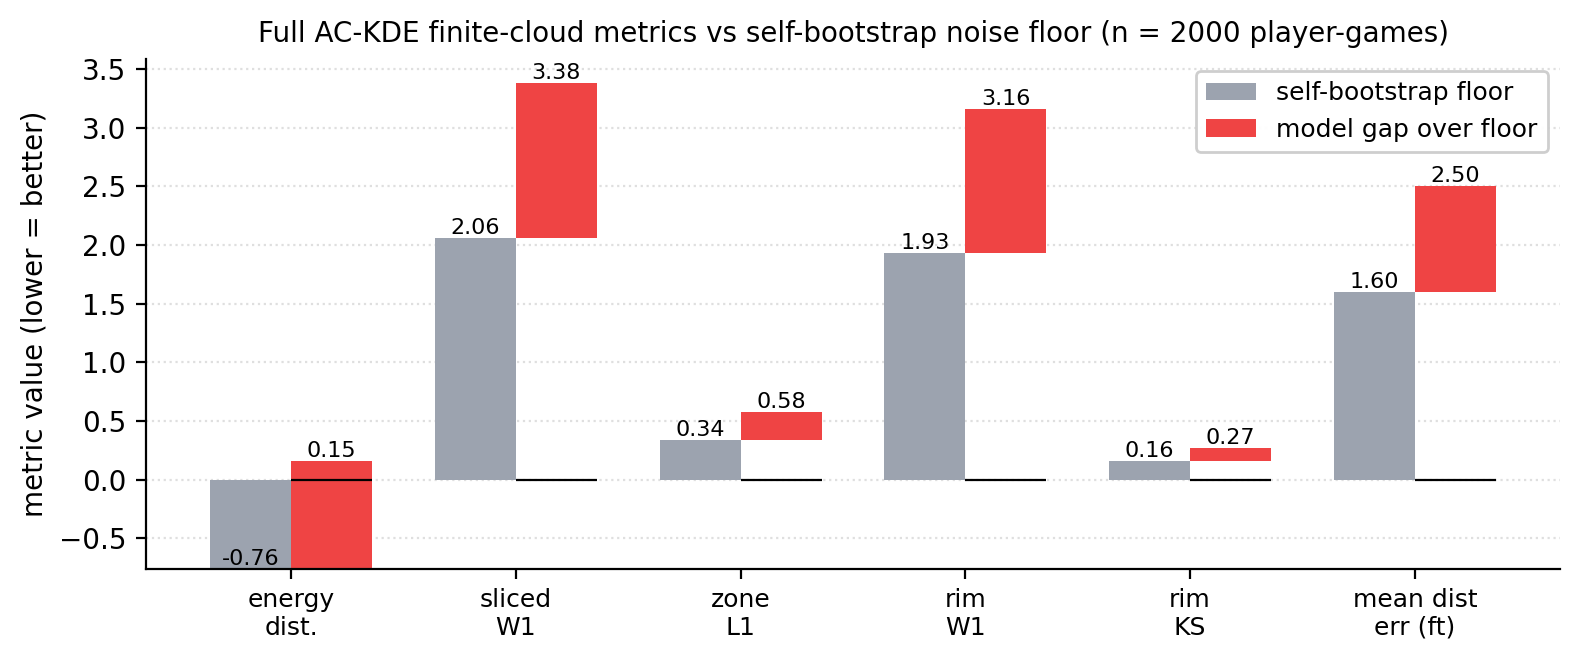

ablation_summary


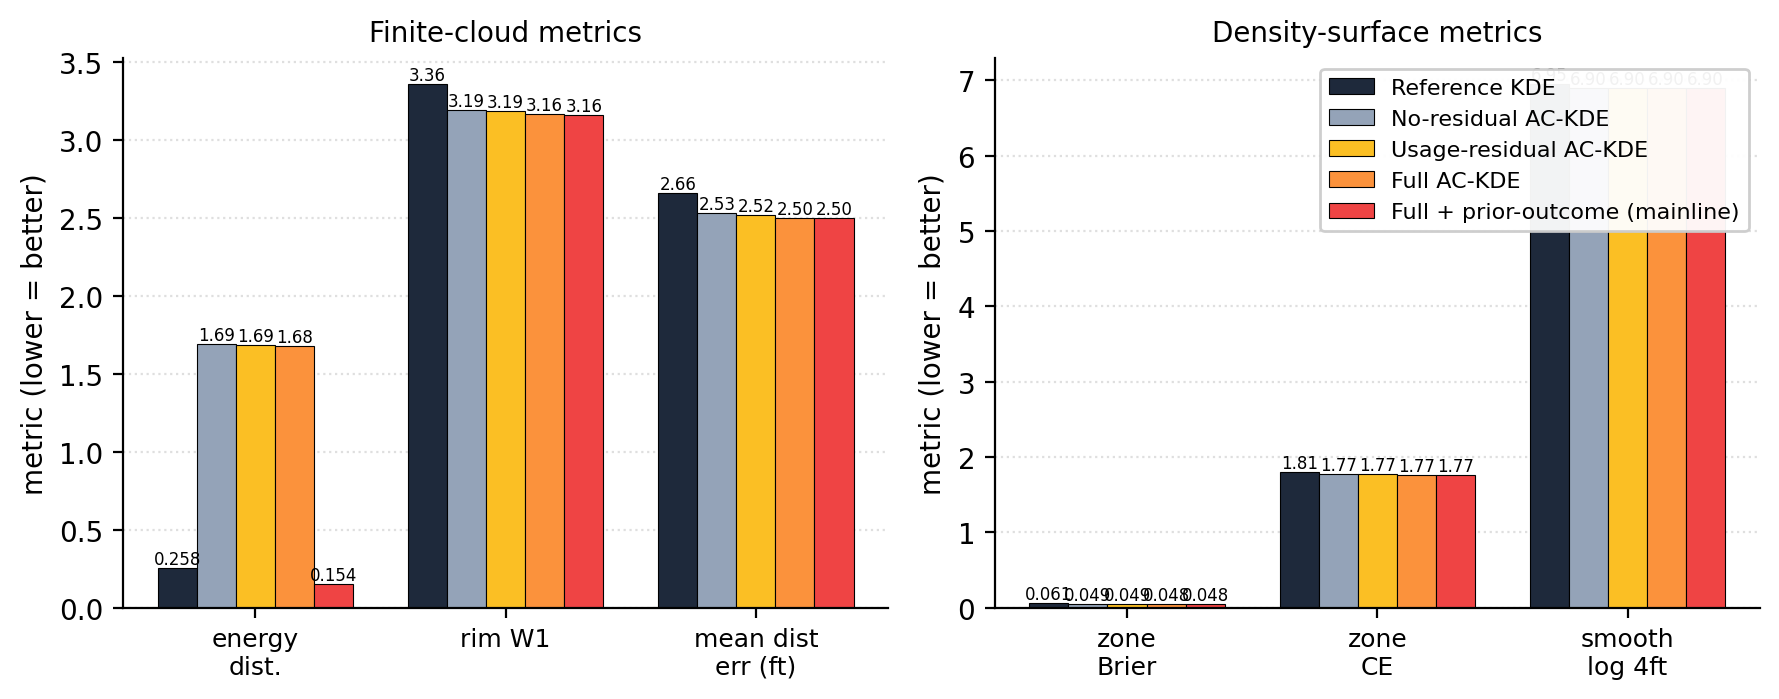

dynamics_history


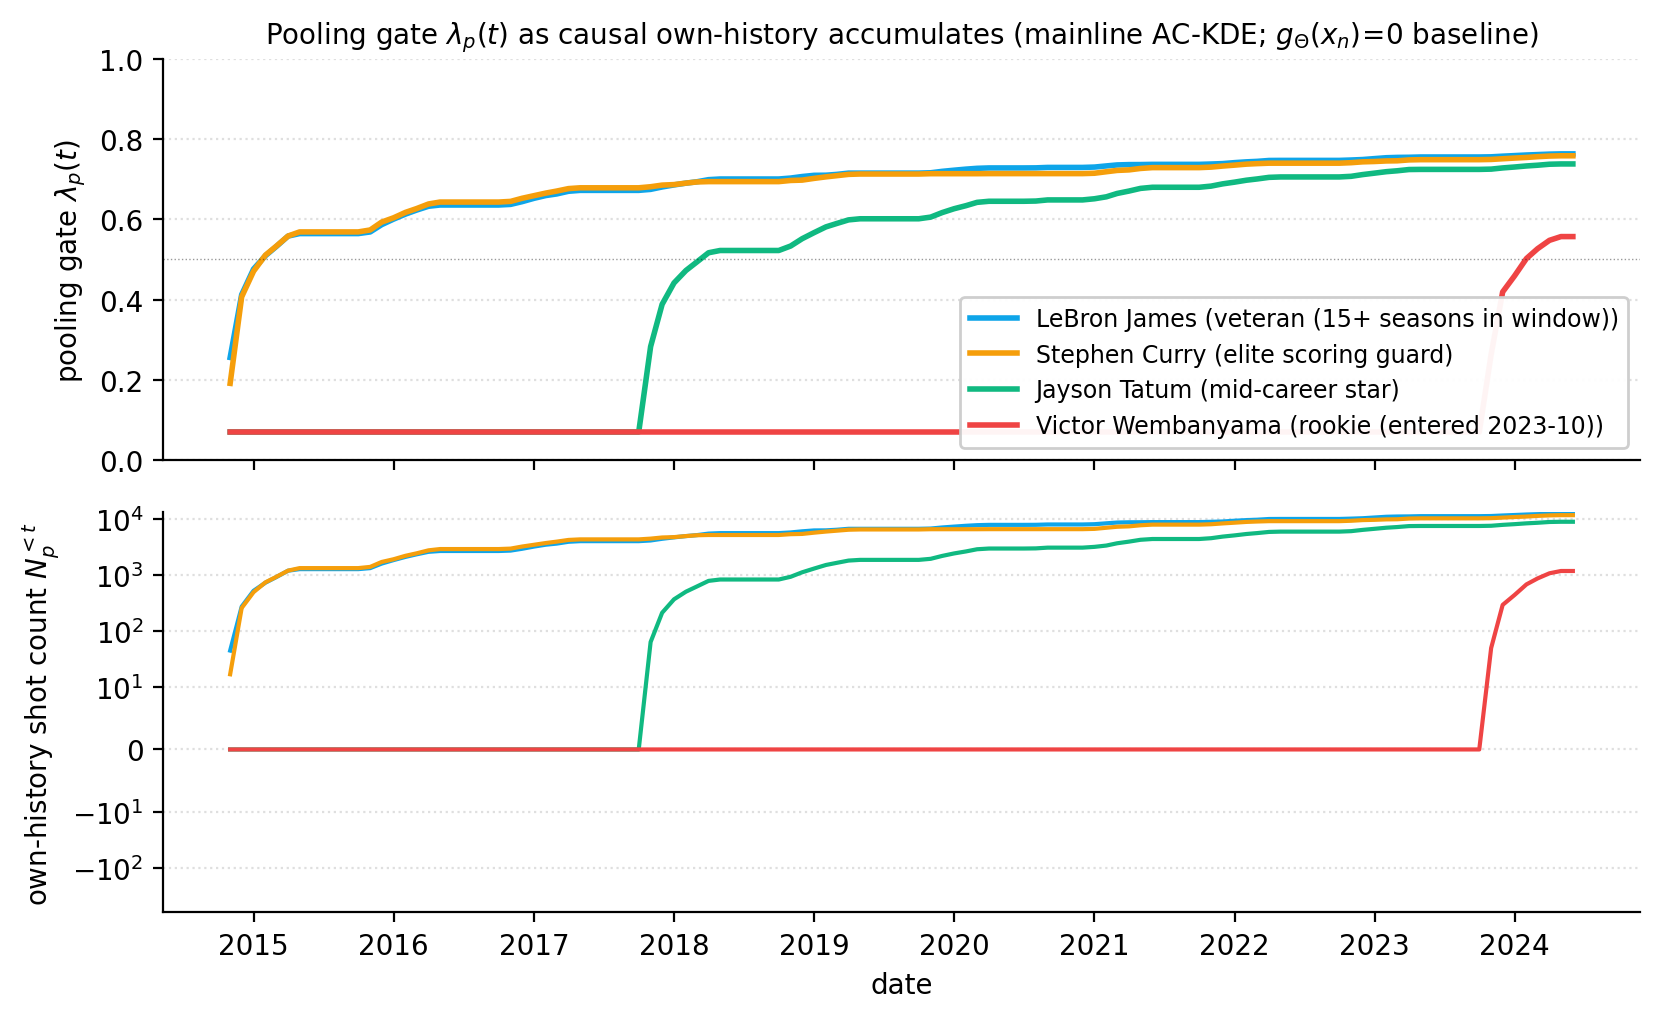

attention_over_support


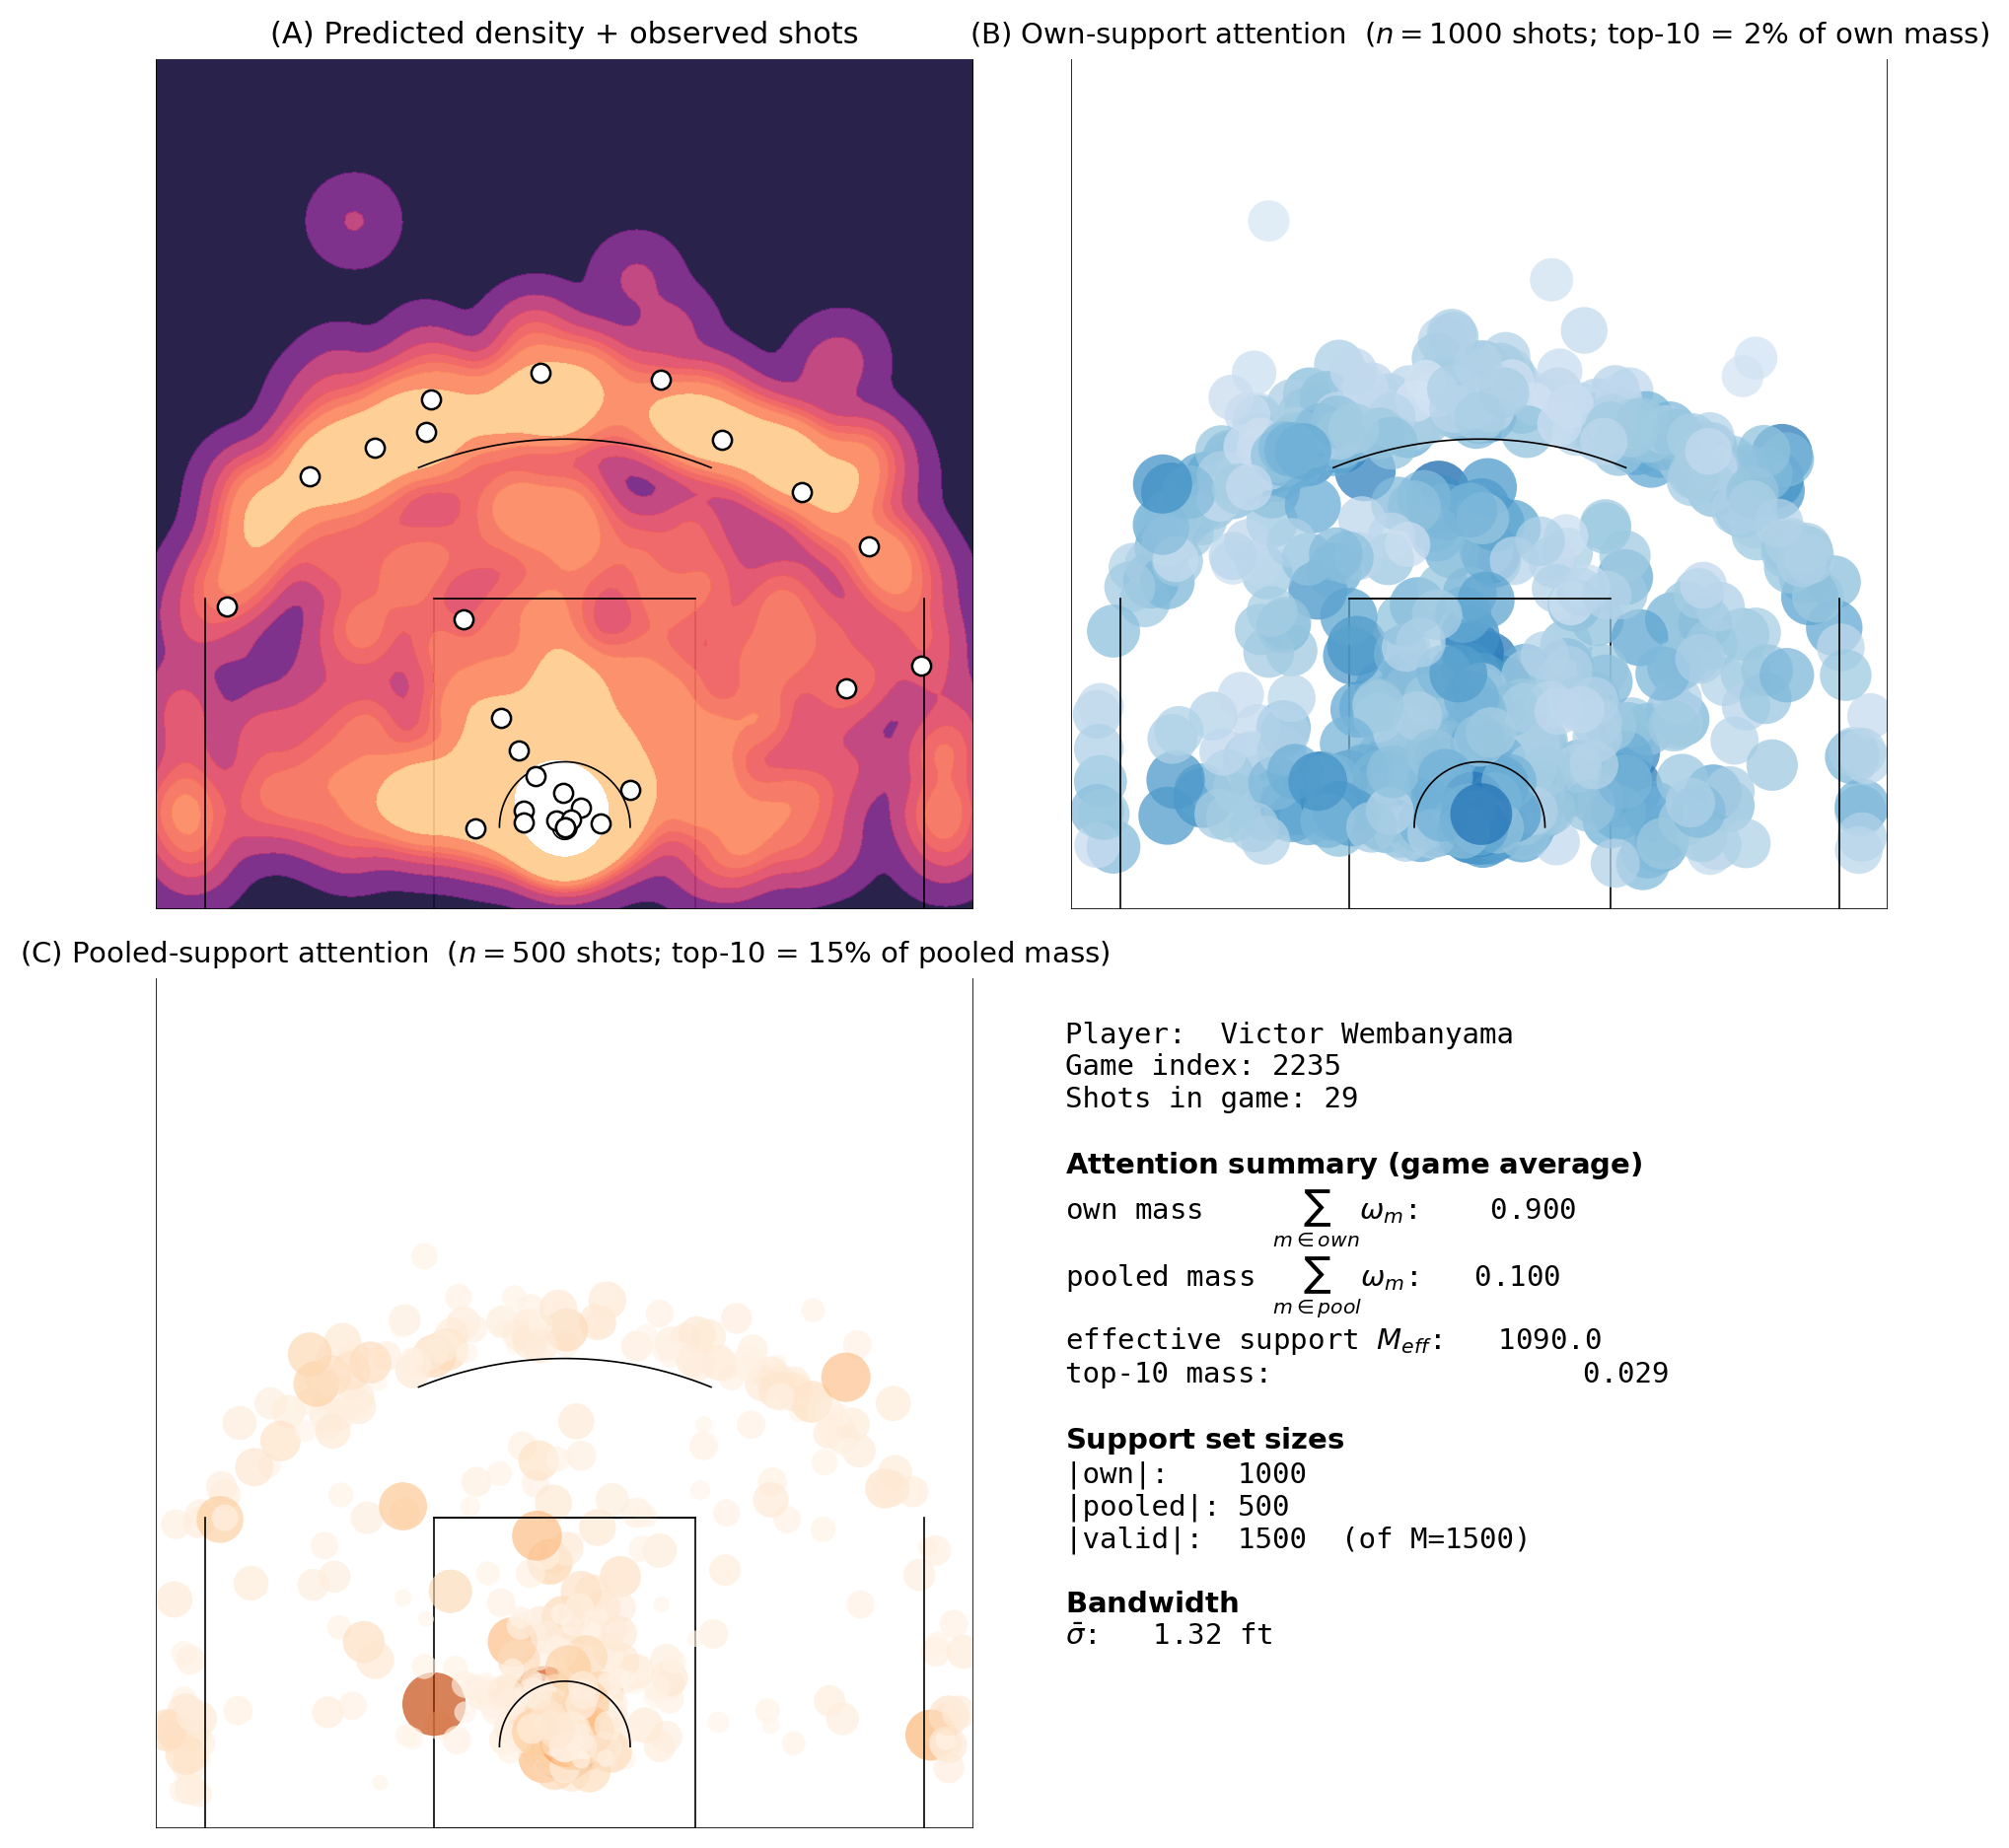

In [11]:
from IPython.display import Image, display

for name in ["self_bootstrap_floor", "ablation_summary", "dynamics_history", "attention_over_support"]:
    path = Path("outputs/figures/paper") / f"{name}.png"
    if path.exists():
        print(name)
        display(Image(filename=str(path), width=900))